## Install dependencies (run once, then restart kernel)

In [1]:
import sys
!{sys.executable} -m pip install torch matplotlib numpy

Defaulting to user installation because normal site-packages is not writeable


## GPU check, imports and global settings

In [2]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# ── Conference-paper global settings ─────────────────────────────────────────
FONT_SIZE  = 20
DPI        = 600
OUTPUT_DIR = "conference_figures_model"
os.makedirs(OUTPUT_DIR, exist_ok=True)

matplotlib.rcParams.update({
    'font.size':        FONT_SIZE,
    'axes.labelsize':   FONT_SIZE,
    'axes.labelweight': 'bold',
    'xtick.labelsize':  FONT_SIZE,
    'ytick.labelsize':  FONT_SIZE,
    'font.weight':      'bold',
    'axes.titlesize':   FONT_SIZE,
    'axes.titleweight': 'bold',
})

def make_bold_ticks(ax):
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontsize(FONT_SIZE)

def save_fig(fig, fname):
    path = os.path.join(OUTPUT_DIR, fname)
    fig.savefig(path, dpi=DPI, bbox_inches='tight')
    print(f"Saved → {path}")

# ── Device ────────────────────────────────────────────────────────────────────
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name        : {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {device}")
print(f"Output folder   : {os.path.abspath(OUTPUT_DIR)}")

PyTorch version : 2.11.0+cpu
CUDA available  : False
Device          : cpu
Output folder   : C:\Users\DYPIU\Downloads\COLON\conference_figures_model


## Define the basic convolution block

In [3]:
class ConvBlock(nn.Module):
    """
    nnU-Net basic block:
    Conv3d → InstanceNorm → LeakyReLU  (×2)
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_channels, out_channels,
                      kernel_size=kernel_size, stride=stride,
                      padding=kernel_size//2, bias=False),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_channels, out_channels,
                      kernel_size=kernel_size, stride=1,
                      padding=kernel_size//2, bias=False),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        return self.block(x)

test_input = torch.zeros(1, 1, 32, 32, 32).to(device)
block      = ConvBlock(1, 32).to(device)
test_out   = block(test_input)
print(f"ConvBlock  Input:{test_input.shape}  →  Output:{test_out.shape}")

ConvBlock  Input:torch.Size([1, 1, 32, 32, 32])  →  Output:torch.Size([1, 32, 32, 32, 32])


## Define encoder and decoder blocks

In [4]:
class EncoderBlock(nn.Module):
    """ConvBlock + strided Conv3d for 2× downsampling."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv       = ConvBlock(in_channels, out_channels)
        self.downsample = nn.Conv3d(out_channels, out_channels,
                                    kernel_size=2, stride=2, bias=False)

    def forward(self, x):
        skip = self.conv(x)
        down = self.downsample(skip)
        return down, skip


class DecoderBlock(nn.Module):
    """ConvTranspose3d upsample + concat skip + ConvBlock."""
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.upsample = nn.ConvTranspose3d(in_channels, out_channels,
                                            kernel_size=2, stride=2)
        self.conv     = ConvBlock(out_channels + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


# Quick tests
enc  = EncoderBlock(1, 32).to(device)
t    = torch.zeros(1, 1, 64, 64, 64).to(device)
down, skip = enc(t)
print(f"EncoderBlock  Input:{t.shape}  Skip:{skip.shape}  Down:{down.shape}")

dec = DecoderBlock(32, 32, 16).to(device)
out = dec(down, skip)
print(f"DecoderBlock  Output:{out.shape}")

EncoderBlock  Input:torch.Size([1, 1, 64, 64, 64])  Skip:torch.Size([1, 32, 64, 64, 64])  Down:torch.Size([1, 32, 32, 32, 32])
DecoderBlock  Output:torch.Size([1, 16, 64, 64, 64])


## Full nnU-Net 3D architecture

In [5]:
class nnUNet(nn.Module):
    """
    nnU-Net 3D Encoder-Decoder with:
      • 5 encoder levels  (strided-conv downsampling)
      • Bottleneck ConvBlock
      • 5 decoder levels  (ConvTranspose3d + skip connections)
      • 3 deep-supervision heads (training only)
      • InstanceNorm + LeakyReLU throughout
    """
    def __init__(self, in_channels=1, out_channels=2,
                 features=(32, 64, 128, 256, 320)):
        super().__init__()
        f = features

        # Encoder
        self.enc1 = EncoderBlock(in_channels, f[0])
        self.enc2 = EncoderBlock(f[0], f[1])
        self.enc3 = EncoderBlock(f[1], f[2])
        self.enc4 = EncoderBlock(f[2], f[3])
        self.enc5 = EncoderBlock(f[3], f[4])

        # Bottleneck
        self.bottleneck = ConvBlock(f[4], f[4])

        # Decoder
        self.dec5 = DecoderBlock(f[4], f[4], f[3])
        self.dec4 = DecoderBlock(f[3], f[3], f[2])
        self.dec3 = DecoderBlock(f[2], f[2], f[1])
        self.dec2 = DecoderBlock(f[1], f[1], f[0])
        self.dec1 = DecoderBlock(f[0], f[0], f[0])

        # Output
        self.out_conv = nn.Conv3d(f[0], out_channels, kernel_size=1)

        # Deep supervision heads
        self.ds4 = nn.Conv3d(f[3], out_channels, kernel_size=1)
        self.ds3 = nn.Conv3d(f[2], out_channels, kernel_size=1)
        self.ds2 = nn.Conv3d(f[1], out_channels, kernel_size=1)

    def forward(self, x):
        x1, s1 = self.enc1(x)
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2)
        x4, s4 = self.enc4(x3)
        x5, s5 = self.enc5(x4)

        b  = self.bottleneck(x5)

        d5 = self.dec5(b,  s5)
        d4 = self.dec4(d5, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)

        out = self.out_conv(d1)

        if self.training:
            return out, self.ds4(d5), self.ds3(d4), self.ds2(d3)
        return out

print("nnU-Net architecture defined.")

nnU-Net architecture defined.


## Test forward pass and model size

In [6]:
model = nnUNet(in_channels=1, out_channels=2).to(device)

dummy = torch.zeros(1, 1, 128, 128, 128).to(device)

model.train()
with torch.no_grad():
    out, ds4, ds3, ds2 = model(dummy)
print("=== Training mode ===")
print(f"  Input      : {dummy.shape}")
print(f"  Main output: {out.shape}")
print(f"  DS-4       : {ds4.shape}")
print(f"  DS-3       : {ds3.shape}")
print(f"  DS-2       : {ds2.shape}")

model.eval()
with torch.no_grad():
    out_eval = model(dummy)
print(f"\n=== Inference mode ===")
print(f"  Output     : {out_eval.shape}")

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n=== Model size ===")
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable:,}")
print(f"  Model size (MB)     : {total_params * 4 / 1024**2:.1f}")

=== Training mode ===
  Input      : torch.Size([1, 1, 128, 128, 128])
  Main output: torch.Size([1, 2, 128, 128, 128])
  DS-4       : torch.Size([1, 2, 8, 8, 8])
  DS-3       : torch.Size([1, 2, 16, 16, 16])
  DS-2       : torch.Size([1, 2, 32, 32, 32])

=== Inference mode ===
  Output     : torch.Size([1, 2, 128, 128, 128])

=== Model size ===
  Total parameters    : 24,705,704
  Trainable parameters: 24,705,704
  Model size (MB)     : 94.2


## Check VRAM usage

In [7]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    model.train()
    test_batch = torch.zeros(2, 1, 128, 128, 128).to(device)
    with torch.no_grad():
        out, ds4, ds3, ds2 = model(test_batch)
    mem_alloc  = torch.cuda.memory_allocated()     / 1024**2
    mem_res    = torch.cuda.memory_reserved()      / 1024**2
    mem_peak   = torch.cuda.max_memory_allocated() / 1024**2
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**2
    print(f"Allocated : {mem_alloc:.0f} MB")
    print(f"Reserved  : {mem_res:.0f} MB")
    print(f"Peak      : {mem_peak:.0f} MB")
    print(f"Total VRAM: {total_vram:.0f} MB")
    print(f"Free VRAM : {total_vram - mem_res:.0f} MB")
    print(f"Batch-2 is {'SAFE' if mem_peak < total_vram * 0.8 else 'TOO LARGE'}")
else:
    mem_peak   = 0
    total_vram = 0
    print("No CUDA device — skipping VRAM check.")

No CUDA device — skipping VRAM check.


## Fig 1 – nnU-Net architecture diagram

Saved → conference_figures_model\fig1_architecture_diagram.png


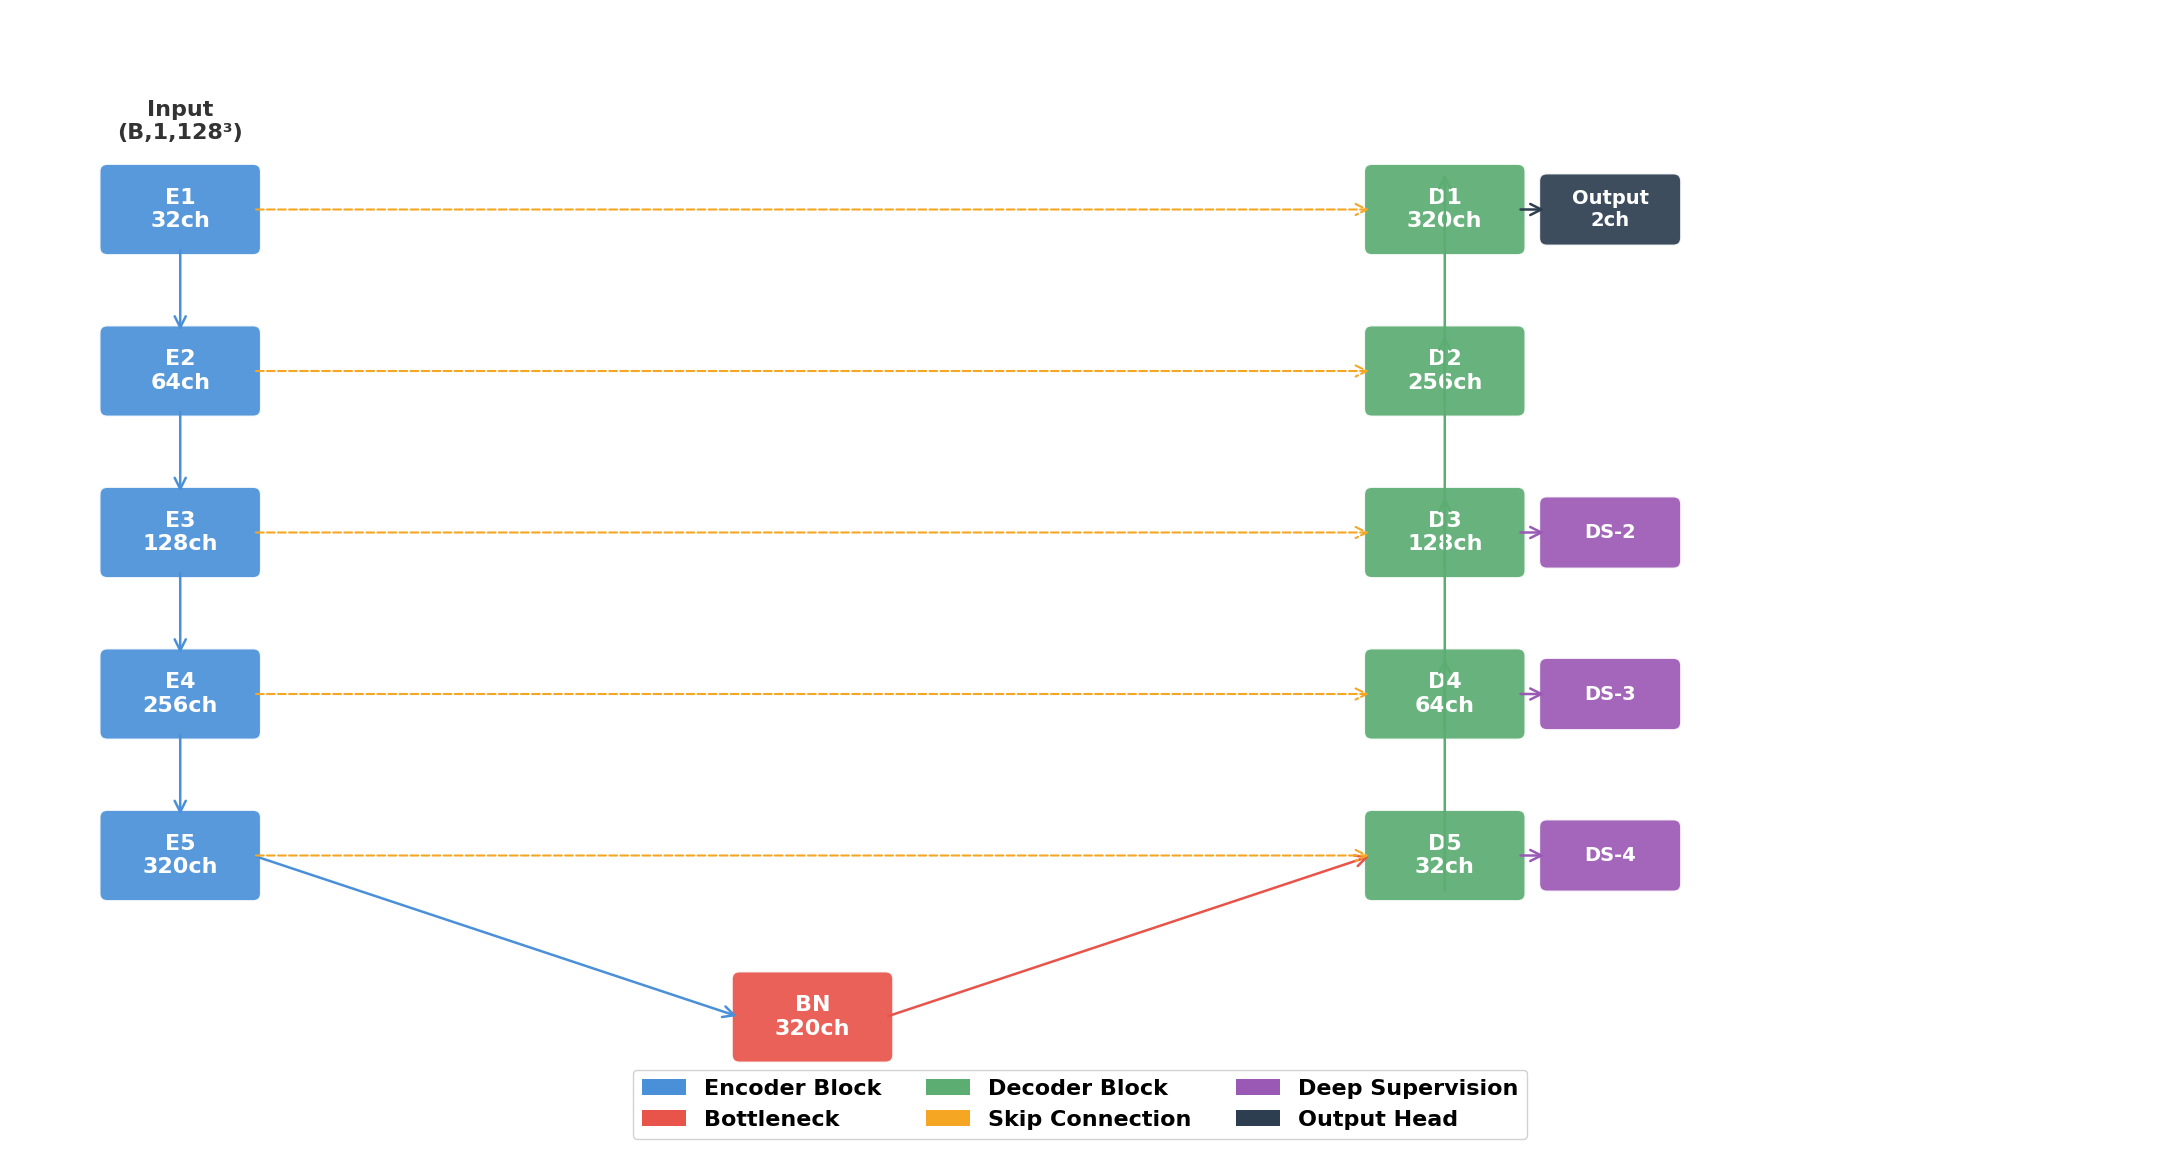

In [8]:
fig, ax = plt.subplots(figsize=(22, 12))
ax.set_xlim(0, 22); ax.set_ylim(0, 12)
ax.axis('off')

# ── colour palette ────────────────────────────────────────────────────────────
C_ENC  = '#4A90D9'   # blue  – encoder
C_BOT  = '#E8544A'   # red   – bottleneck
C_DEC  = '#5BAD72'   # green – decoder
C_SKIP = '#F5A623'   # amber – skip
C_DS   = '#9B59B6'   # purple– deep supervision
C_OUT  = '#2C3E50'   # dark  – output

def draw_box(ax, x, y, w, h, color, label, fs=FONT_SIZE-4):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.08",
        facecolor=color, edgecolor='white', linewidth=1.5, alpha=0.92, zorder=3))
    ax.text(x + w/2, y + h/2, label, ha='center', va='center',
            fontsize=fs, fontweight='bold', color='white', zorder=4)

def arrow(ax, x1, y1, x2, y2, color='#555555', lw=1.8, style='->'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color,
                                lw=lw, connectionstyle='arc3,rad=0.0'),
                zorder=5)

# ── layout constants ──────────────────────────────────────────────────────────
BW, BH   = 1.5, 0.8      # box width / height
ENC_Y    = [9.5, 7.8, 6.1, 4.4, 2.7]   # encoder row y-coords
DEC_Y    = [9.5, 7.8, 6.1, 4.4, 2.7]   # decoder  row y-coords
ENC_X    = 1.0
DEC_X    = 14.0
BOT_X, BOT_Y = 7.5, 1.0
FEATS    = [32, 64, 128, 256, 320]

# ── encoder ──────────────────────────────────────────────────────────────────
for i, (y, f) in enumerate(zip(ENC_Y, FEATS)):
    draw_box(ax, ENC_X, y, BW, BH, C_ENC, f'E{i+1}\n{f}ch')
    if i < len(ENC_Y)-1:
        arrow(ax, ENC_X+BW/2, y, ENC_X+BW/2, ENC_Y[i+1]+BH, '#4A90D9')

# ── bottleneck ────────────────────────────────────────────────────────────────
draw_box(ax, BOT_X, BOT_Y, BW, BH, C_BOT, f'BN\n320ch')
# enc5 → bottleneck
arrow(ax, ENC_X+BW, ENC_Y[4]+BH/2, BOT_X, BOT_Y+BH/2, '#4A90D9')

# ── decoder ──────────────────────────────────────────────────────────────────
for i, (y, f) in enumerate(zip(DEC_Y, FEATS[::-1])):
    draw_box(ax, DEC_X, y, BW, BH, C_DEC, f'D{i+1}\n{f}ch')
    if i < len(DEC_Y)-1:
        arrow(ax, DEC_X+BW/2, DEC_Y[i+1], DEC_X+BW/2, y+BH, '#5BAD72')

# bottleneck → dec1 (top of decoder = dec5 in code = FEATS[3]=256)
arrow(ax, BOT_X+BW, BOT_Y+BH/2, DEC_X, DEC_Y[4]+BH/2, C_BOT)

# ── skip connections ──────────────────────────────────────────────────────────
for i in range(5):
    x1s = ENC_X + BW
    x2s = DEC_X
    ym  = ENC_Y[i] + BH/2
    ax.annotate('', xy=(x2s, ym), xytext=(x1s, ym),
                arrowprops=dict(arrowstyle='->', color=C_SKIP,
                                lw=1.5, linestyle='dashed',
                                connectionstyle='arc3,rad=0.0'), zorder=5)

# ── deep supervision ─────────────────────────────────────────────────────────
for i, (dec_idx, label) in enumerate(zip([4, 3, 2], ['DS-4','DS-3','DS-2'])):
    ds_x = DEC_X + BW + 0.3
    ds_y = DEC_Y[dec_idx] + BH/2 - 0.3
    draw_box(ax, ds_x, ds_y, 1.3, 0.6, C_DS, label, fs=FONT_SIZE-6)
    arrow(ax, DEC_X+BW, DEC_Y[dec_idx]+BH/2, ds_x, ds_y+0.3, C_DS)

# ── output head ──────────────────────────────────────────────────────────────
out_x = DEC_X + BW + 0.3
out_y = DEC_Y[0] + BH/2 - 0.3
draw_box(ax, out_x, out_y, 1.3, 0.6, C_OUT, 'Output\n2ch', fs=FONT_SIZE-6)
arrow(ax, DEC_X+BW, DEC_Y[0]+BH/2, out_x, out_y+0.3, C_OUT)

# ── input label ──────────────────────────────────────────────────────────────
ax.text(ENC_X+BW/2, ENC_Y[0]+BH+0.3, 'Input\n(B,1,128³)',
        ha='center', va='bottom', fontsize=FONT_SIZE-4, fontweight='bold', color='#333')

# ── legend ───────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_ENC,  label='Encoder Block'),
    mpatches.Patch(facecolor=C_BOT,  label='Bottleneck'),
    mpatches.Patch(facecolor=C_DEC,  label='Decoder Block'),
    mpatches.Patch(facecolor=C_SKIP, label='Skip Connection'),
    mpatches.Patch(facecolor=C_DS,   label='Deep Supervision'),
    mpatches.Patch(facecolor=C_OUT,  label='Output Head'),
]
leg = ax.legend(handles=legend_items, loc='lower center',
                ncol=3, fontsize=FONT_SIZE-4,
                framealpha=0.9, edgecolor='#ccc')
for t in leg.get_texts():
    t.set_fontweight('bold')

ax.set_xlabel('(a) nnU-Net 3D Architecture', fontweight='bold', fontsize=FONT_SIZE)

fig.tight_layout()
save_fig(fig, 'fig1_architecture_diagram.png')
plt.show()

## Fig 2 – Feature map sizes through the network (table plot)

Saved → conference_figures_model\fig2_feature_map_sizes.png


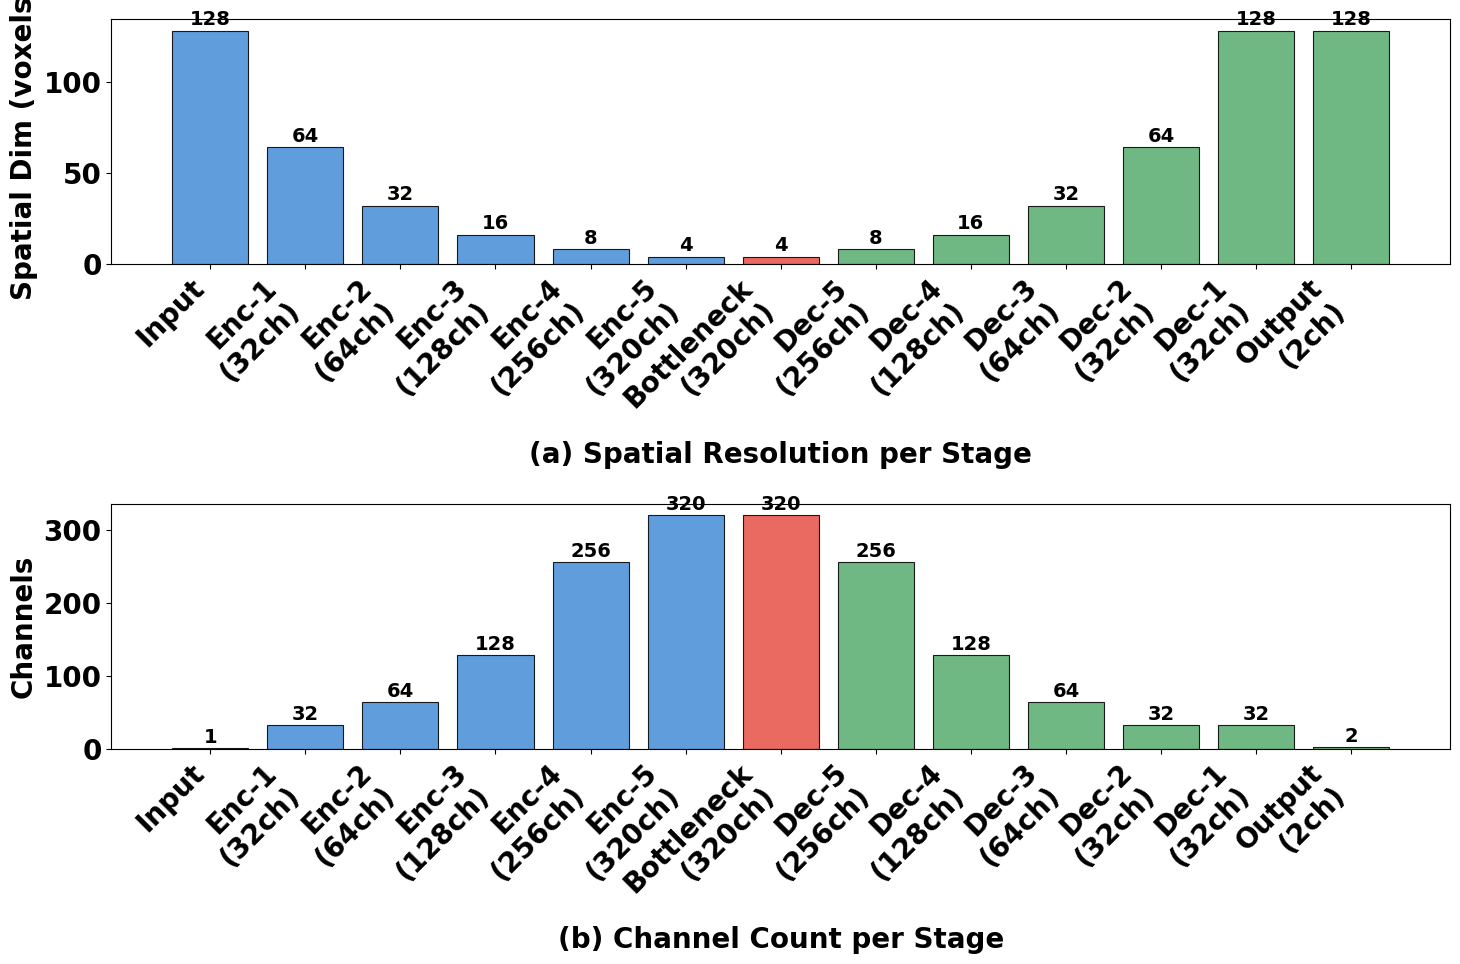

In [14]:
stages = [
    'Input',
    'Enc-1\n(32ch)', 'Enc-2\n(64ch)',  'Enc-3\n(128ch)',
    'Enc-4\n(256ch)', 'Enc-5\n(320ch)',
    'Bottleneck\n(320ch)',
    'Dec-5\n(256ch)', 'Dec-4\n(128ch)', 'Dec-3\n(64ch)',
    'Dec-2\n(32ch)',  'Dec-1\n(32ch)',  'Output\n(2ch)',
]
spatial = [
    128,
    64,  32,  16,
    8,   4,
    4,
    8,   16,  32,
    64,  128, 128,
]
channels = [
    1,
    32,  64,  128,
    256, 320,
    320,
    256, 128, 64,
    32,  32,  2,
]

x_pos = np.arange(len(stages))

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ── spatial size ─────────────────────────────────────────────────────────────
colors_sp = ['#4A90D9']*6 + ['#E8544A'] + ['#5BAD72']*6
axes[0].bar(x_pos, spatial, color=colors_sp, edgecolor='black', linewidth=0.8, alpha=0.88)
axes[0].set_ylabel('Spatial Dim (voxels)',   fontweight='bold', fontsize=FONT_SIZE)
axes[0].set_xlabel('(a) Spatial Resolution per Stage',
                    fontweight='bold', fontsize=FONT_SIZE)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(stages, fontsize=FONT_SIZE-4, fontweight='bold', rotation=45, ha='right')
make_bold_ticks(axes[0])
for i, v in enumerate(spatial):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=FONT_SIZE-6,
                 fontweight='bold', va='bottom')

# ── channel count ─────────────────────────────────────────────────────────────
colors_ch = ['#4A90D9']*6 + ['#E8544A'] + ['#5BAD72']*6
axes[1].bar(x_pos, channels, color=colors_ch, edgecolor='black', linewidth=0.8, alpha=0.88)
axes[1].set_ylabel('Channels',               fontweight='bold', fontsize=FONT_SIZE)
axes[1].set_xlabel('(b) Channel Count per Stage',
                    fontweight='bold', fontsize=FONT_SIZE)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(stages, fontsize=FONT_SIZE-4, fontweight='bold', rotation=45, ha='right')
make_bold_ticks(axes[1])
for i, v in enumerate(channels):
    axes[1].text(i, v + 2, str(v), ha='center', fontsize=FONT_SIZE-6,
                 fontweight='bold', va='bottom')

fig.tight_layout()
save_fig(fig, 'fig2_feature_map_sizes.png')
plt.show()

## Fig 3 – Parameter distribution by module (bar chart)

C:\Users\DYPIU\AppData\Local\Temp\ipykernel_24504\3054652775.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, fontweight='bold', fontsize=FONT_SIZE-2, rotation=45, ha='right')


Saved → conference_figures_model\fig3_parameter_distribution.png


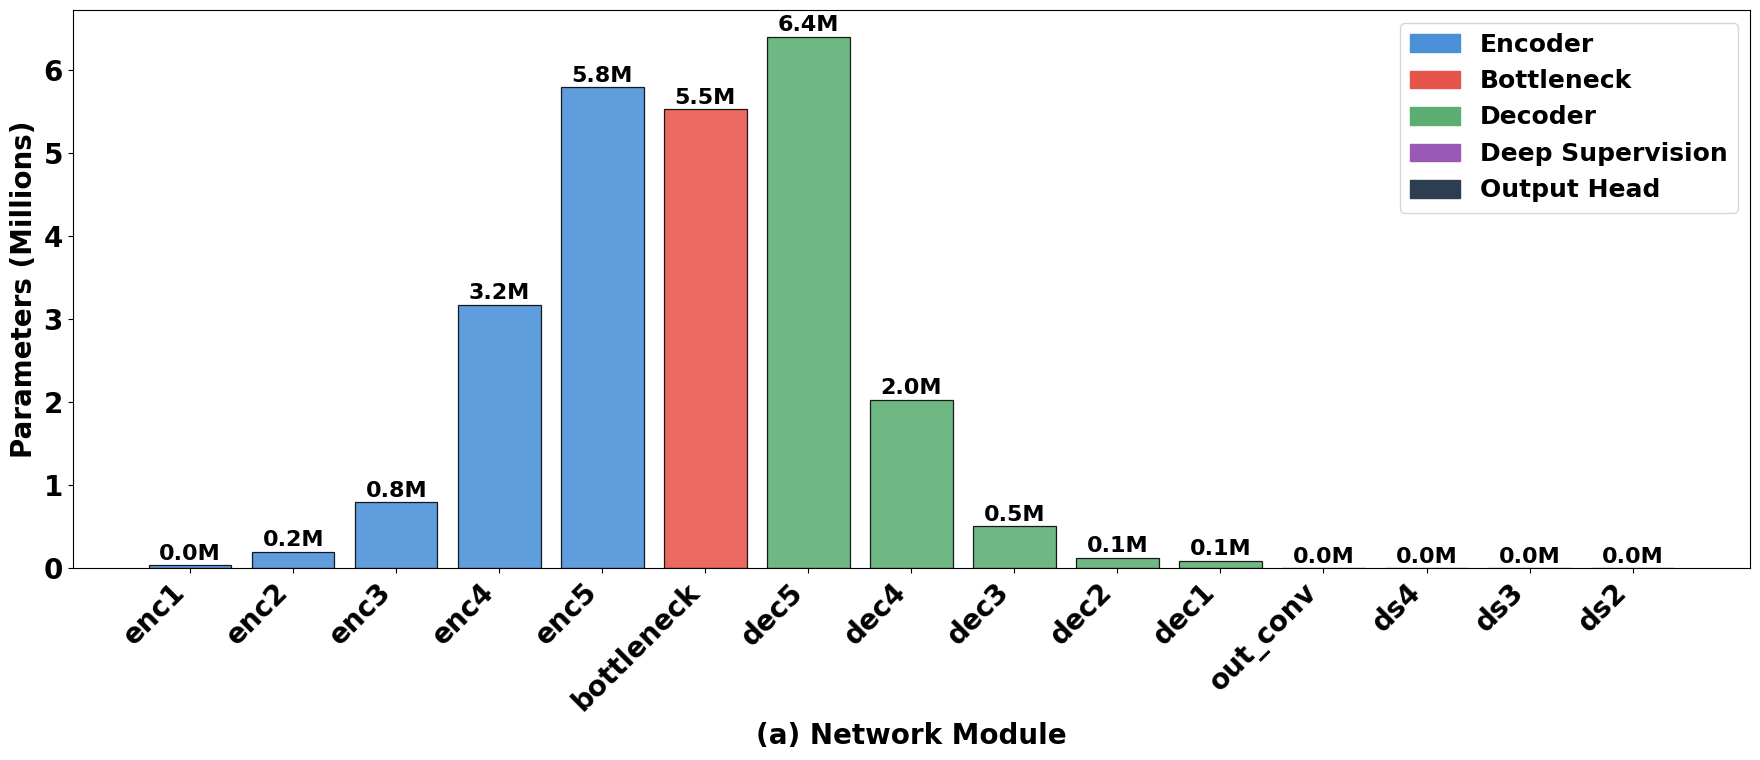

Total: 24.7 M  (24705704 parameters)


In [10]:
module_params = {}
for name, mod in model.named_children():
    n = sum(p.numel() for p in mod.parameters())
    module_params[name] = n

names  = list(module_params.keys())
counts = [module_params[n] / 1e6 for n in names]   # millions

# colour by type
def _col(n):
    if n.startswith('enc'): return '#4A90D9'
    if n == 'bottleneck':   return '#E8544A'
    if n.startswith('dec'): return '#5BAD72'
    if n.startswith('ds'):  return '#9B59B6'
    return '#2C3E50'

bar_colors = [_col(n) for n in names]

fig, ax = plt.subplots(figsize=(18, 8))
bars = ax.bar(names, counts, color=bar_colors, edgecolor='black', linewidth=0.9, alpha=0.88)

ax.set_xlabel('(a) Network Module',        fontweight='bold', fontsize=FONT_SIZE)
ax.set_ylabel('Parameters (Millions)',     fontweight='bold', fontsize=FONT_SIZE)
ax.set_xticklabels(names, fontweight='bold', fontsize=FONT_SIZE-2, rotation=45, ha='right')
make_bold_ticks(ax)

for bar, v in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{v:.1f}M', ha='center', va='bottom',
            fontweight='bold', fontsize=FONT_SIZE-4)

legend_items = [
    mpatches.Patch(color='#4A90D9', label='Encoder'),
    mpatches.Patch(color='#E8544A', label='Bottleneck'),
    mpatches.Patch(color='#5BAD72', label='Decoder'),
    mpatches.Patch(color='#9B59B6', label='Deep Supervision'),
    mpatches.Patch(color='#2C3E50', label='Output Head'),
]
leg = ax.legend(handles=legend_items, fontsize=FONT_SIZE-2, loc='upper right')
for t in leg.get_texts():
    t.set_fontweight('bold')

fig.tight_layout()
save_fig(fig, 'fig3_parameter_distribution.png')
plt.show()

total_m = sum(counts)
print(f"Total: {total_m:.1f} M  ({total_m*1e6:.0f} parameters)")

## Fig 4 – VRAM usage breakdown (bar chart)

C:\Users\DYPIU\AppData\Local\Temp\ipykernel_24504\871033666.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontweight='bold', fontsize=FONT_SIZE)


Saved → conference_figures_model\fig4_vram_usage.png


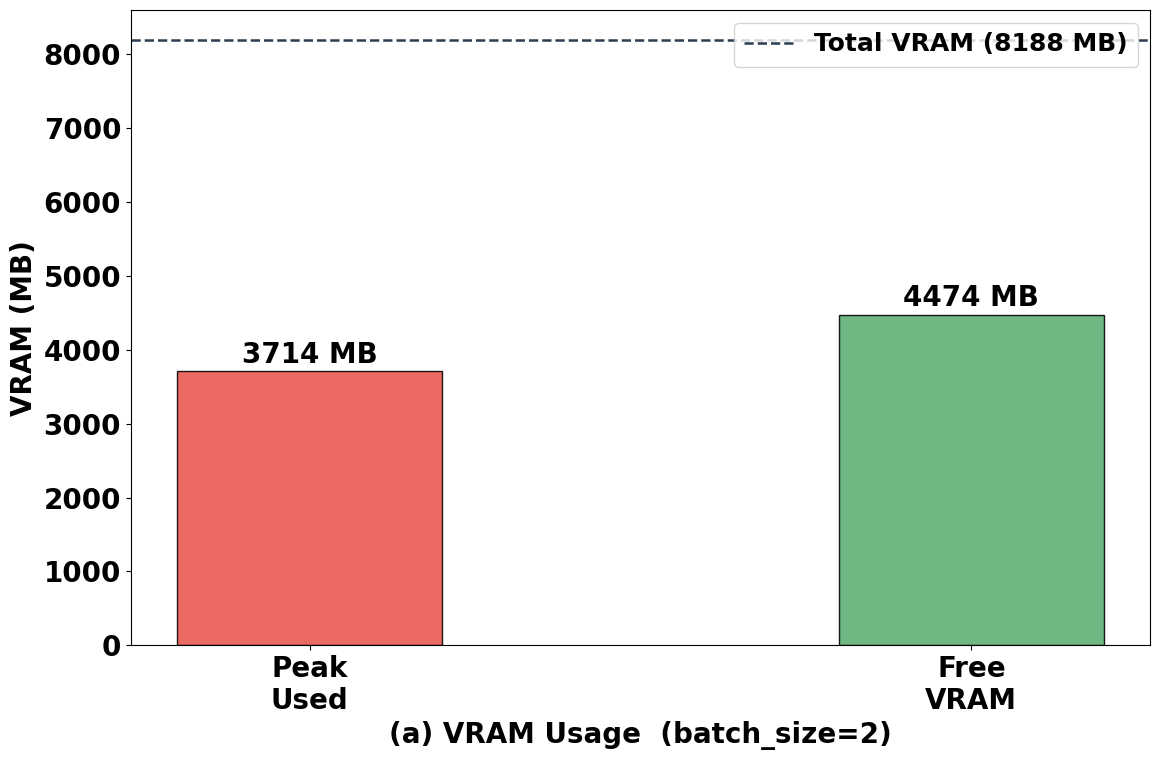

In [17]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    model.train()
    test_batch = torch.zeros(2, 1, 128, 128, 128).to(device)
    with torch.no_grad():
        _ = model(test_batch)
    mem_peak   = torch.cuda.max_memory_allocated() / 1024
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024
    free_vram  = total_vram - mem_peak
else:
    mem_peak   = 3714
    total_vram = 8188
    free_vram  = total_vram - mem_peak

labels = ['Peak\nUsed', 'Free\nVRAM']
values = [mem_peak, free_vram]
cols   = ['#E8544A', '#5BAD72']

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(labels, values, color=cols, edgecolor='black', linewidth=1.0,
              width=0.4, alpha=0.88)

ax.set_ylabel('VRAM (MB)',                    fontweight='bold', fontsize=FONT_SIZE)
ax.set_xlabel('(a) VRAM Usage  (batch_size=2)', fontweight='bold', fontsize=FONT_SIZE)
ax.set_xticklabels(labels, fontweight='bold', fontsize=FONT_SIZE)
make_bold_ticks(ax)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{v:.0f} MB', ha='center', va='bottom',
            fontweight='bold', fontsize=FONT_SIZE)

ax.axhline(total_vram, color='#2C3E50', linestyle='--', linewidth=1.8, label=f'Total VRAM ({total_vram:.0f} MB)')
leg = ax.legend(fontsize=FONT_SIZE-2)
for t in leg.get_texts():
    t.set_fontweight('bold')

fig.tight_layout()
save_fig(fig, 'fig4_vram_usage.png')
plt.show()

## Fig 5 – ConvBlock internals diagram

Saved → conference_figures_model\fig5_convblock_diagram.png


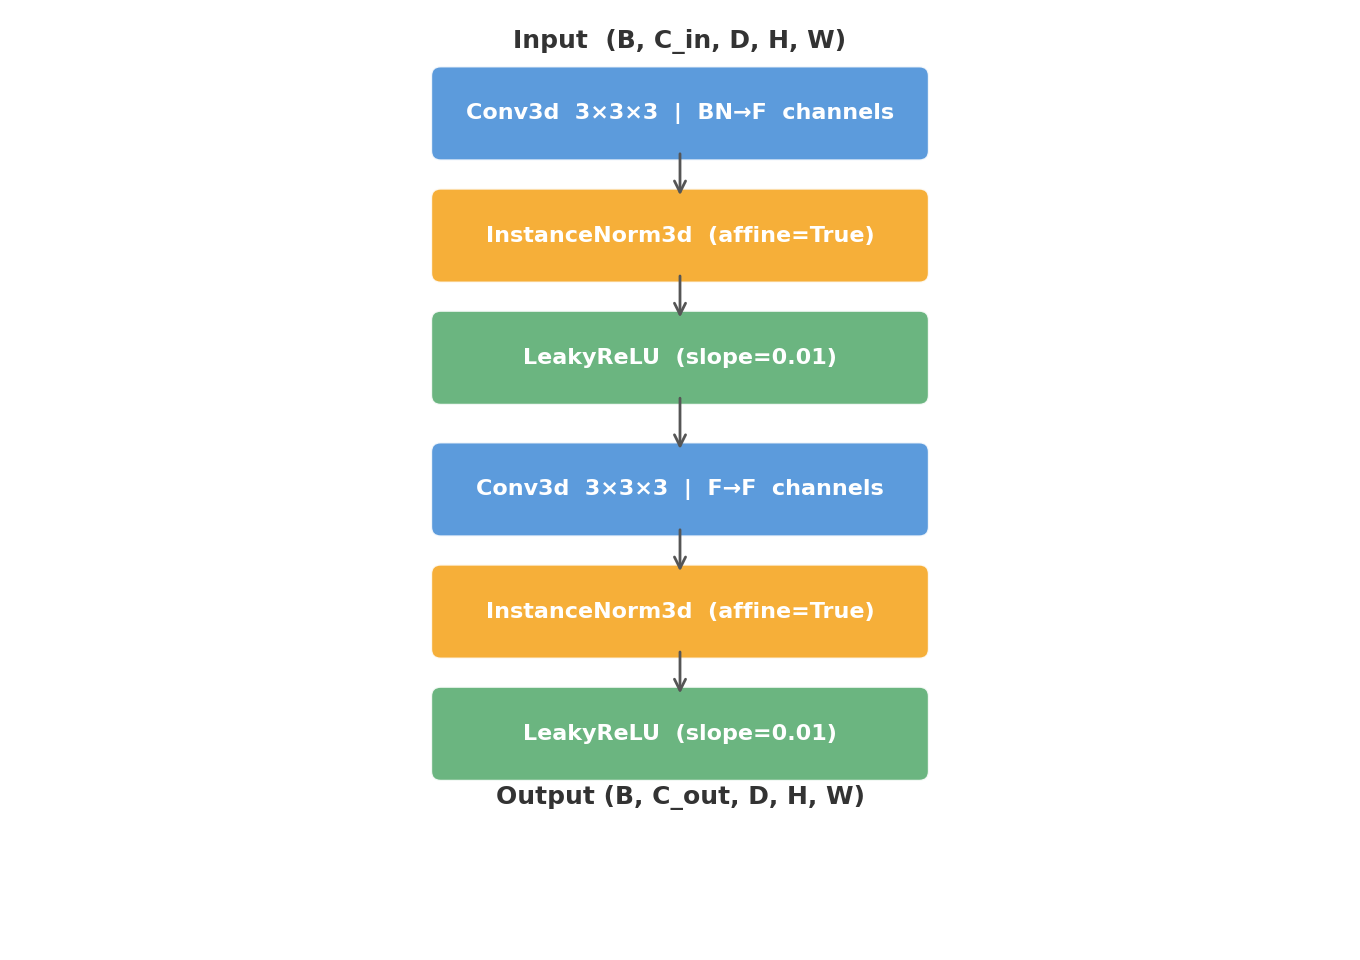

In [12]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 14); ax.set_ylim(0, 10)
ax.axis('off')

C_CONV = '#4A90D9'
C_IN   = '#F5A623'
C_ACT  = '#5BAD72'
C_ARR  = '#555555'

steps = [
    (4.5, 8.5, 5.0, 0.8, C_CONV, 'Conv3d  3×3×3  |  BN→F  channels', FONT_SIZE-4),
    (4.5, 7.2, 5.0, 0.8, C_IN,   'InstanceNorm3d  (affine=True)',        FONT_SIZE-4),
    (4.5, 5.9, 5.0, 0.8, C_ACT,  'LeakyReLU  (slope=0.01)',              FONT_SIZE-4),
    (4.5, 4.5, 5.0, 0.8, C_CONV, 'Conv3d  3×3×3  |  F→F  channels',    FONT_SIZE-4),
    (4.5, 3.2, 5.0, 0.8, C_IN,   'InstanceNorm3d  (affine=True)',        FONT_SIZE-4),
    (4.5, 1.9, 5.0, 0.8, C_ACT,  'LeakyReLU  (slope=0.01)',              FONT_SIZE-4),
]

for (x, y, w, h, col, lbl, fs) in steps:
    ax.add_patch(mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle="round,pad=0.1",
        facecolor=col, edgecolor='white', linewidth=1.5, alpha=0.90, zorder=3))
    ax.text(x + w/2, y + h/2, lbl, ha='center', va='center',
            fontsize=fs, fontweight='bold', color='white', zorder=4)

# arrows between steps
ys = [s[1] for s in steps]
for i in range(len(ys)-1):
    ax.annotate('', xy=(7.0, ys[i+1]+0.8), xytext=(7.0, ys[i]),
                arrowprops=dict(arrowstyle='->', color=C_ARR, lw=2.0), zorder=5)

# input / output labels
ax.text(7.0, 9.6,  'Input  (B, C_in, D, H, W)',  ha='center', fontsize=FONT_SIZE-2,
        fontweight='bold', color='#333')
ax.text(7.0, 1.55, 'Output (B, C_out, D, H, W)', ha='center', fontsize=FONT_SIZE-2,
        fontweight='bold', color='#333')

ax.set_xlabel('(a) ConvBlock: Two Conv-IN-LReLU Stages',
              fontweight='bold', fontsize=FONT_SIZE)

fig.tight_layout()
save_fig(fig, 'fig5_convblock_diagram.png')
plt.show()

## Model notebook — final summary

In [13]:
total_params = sum(p.numel() for p in model.parameters())
print("=" * 60)
print("MODEL NOTEBOOK — COMPLETE SUMMARY")
print("=" * 60)

print(f"\n ARCHITECTURE: nnU-Net 3D")
print(f"   Encoder levels    : 5")
print(f"   Feature maps      : [32, 64, 128, 256, 320]")
print(f"   Downsampling      : Strided Conv3d (2×2×2)")
print(f"   Upsampling        : ConvTranspose3d (2×2×2)")
print(f"   Normalisation     : Instance Normalisation")
print(f"   Activation        : LeakyReLU (slope=0.01)")
print(f"   Skip connections  : Yes (U-Net style)")
print(f"   Deep supervision  : 3 auxiliary heads")

print(f"\n MODEL STATISTICS")
print(f"   Total parameters  : {total_params:,}")
print(f"   Model size        : {total_params * 4 / 1024**2:.1f} MB")
print(f"   Input shape       : (B, 1, 128, 128, 128)")
print(f"   Output shape      : (B, 2, 128, 128, 128)")

print(f"\n FIGURES SAVED TO  {os.path.abspath(OUTPUT_DIR)}/")
for fn in ['fig1_architecture_diagram.png',
           'fig2_feature_map_sizes.png',
           'fig3_parameter_distribution.png',
           'fig4_vram_usage.png',
           'fig5_convblock_diagram.png']:
    print(f"   {fn}")
print("=" * 60)

MODEL NOTEBOOK — COMPLETE SUMMARY

 ARCHITECTURE: nnU-Net 3D
   Encoder levels    : 5
   Feature maps      : [32, 64, 128, 256, 320]
   Downsampling      : Strided Conv3d (2×2×2)
   Upsampling        : ConvTranspose3d (2×2×2)
   Normalisation     : Instance Normalisation
   Activation        : LeakyReLU (slope=0.01)
   Skip connections  : Yes (U-Net style)
   Deep supervision  : 3 auxiliary heads

 MODEL STATISTICS
   Total parameters  : 24,705,704
   Model size        : 94.2 MB
   Input shape       : (B, 1, 128, 128, 128)
   Output shape      : (B, 2, 128, 128, 128)

 FIGURES SAVED TO  C:\Users\DYPIU\Downloads\COLON\conference_figures_model/
   fig1_architecture_diagram.png
   fig2_feature_map_sizes.png
   fig3_parameter_distribution.png
   fig4_vram_usage.png
   fig5_convblock_diagram.png
